In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, PrecisionRecallDisplay, confusion_matrix, ConfusionMatrixDisplay, \
    precision_recall_curve

from joblib import parallel_backend
import joblib
import sys

In [7]:
sys.path.append('..')
from backend.data_pipeline import get_preprocessor

In [8]:
df = pd.read_csv(r'../data/raw/bank-additional-full.csv', sep = ';')
df.drop(columns = ['duration', 'pdays', 'default', 'emp.var.rate', 'nr.employed'], inplace = True)
df['y'] = np.where(df['y'] == 'yes', 1, 0)
df = df.replace('unknown', np.nan)

In [9]:
X = df.drop(columns = ['y'])
y = df['y']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)
preprocessor = get_preprocessor()

In [11]:
models = {
    'RandomForest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=42),
    'LogisticRegression': LogisticRegression(random_state=42, n_jobs=-1),
}

In [12]:
param_grid = {
    'RandomForest': {
        'smote__k_neighbors': [3, 5],
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_split': [2, 5, 10]
    },
    'HistGradientBoosting': {
        'smote__k_neighbors': [3, 5],
        'model__learning_rate': [0.01, 0.1],
        'model__max_iter': [100, 200],
    },
    'LogisticRegression': {
        'smote__k_neighbors': [3, 5],
        'model__C': [0.1, 1.0, 10.0]
    }
}

In [13]:
results = []
best_estimators = {}

with parallel_backend('threading', n_jobs=-1):
    for name, estimator in models.items():
        pipeline = ImbPipeline(steps=[
            ('preprocessor', preprocessor),
            ('smote', SMOTE(random_state=42)),
            ('model', models[name])
        ])

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid[name],
            scoring='f1',
            cv=skf,
            n_jobs=3,
            verbose=2
        )

        grid_search.fit(X_train, y_train)

        best_estimators[name] = grid_search.best_estimator_
        results.append({
            'Model': name,
            'Best CV F1': np.round(grid_search.best_score_, 4),
            'Best params': grid_search.best_params_
        })

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100, smote__k_neighbors=3; total time=   7.4s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100, smote__k_neighbors=3; total time=   7.4s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100, smote__k_neighbors=3; total time=   7.5s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100, smote__k_neighbors=3; total time=   4.1s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100, smote__k_neighbors=3; total time=   4.6s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100, smote__k_neighbors=5; total time=   5.6s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100, smote__k_neighbors=5; total time=   3.7s
[CV] END model__max_depth=None, model__min_samples_split

D:\Pulpit\bank_marketing_e2e_proj\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
D:\Pulpit\bank_marketing_e2e_proj\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
D:\Pulpit\bank_marketing_e2e_proj\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


[CV] END .................model__C=0.1, smote__k_neighbors=3; total time=   0.8s
[CV] END .................model__C=0.1, smote__k_neighbors=3; total time=   0.9s
[CV] END .................model__C=0.1, smote__k_neighbors=3; total time=   0.9s


D:\Pulpit\bank_marketing_e2e_proj\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
D:\Pulpit\bank_marketing_e2e_proj\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
D:\Pulpit\bank_marketing_e2e_proj\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


[CV] END .................model__C=0.1, smote__k_neighbors=3; total time=   0.9s
[CV] END .................model__C=0.1, smote__k_neighbors=3; total time=   1.0s
[CV] END .................model__C=0.1, smote__k_neighbors=5; total time=   1.0s


...

D:\Pulpit\bank_marketing_e2e_proj\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


[CV] END ................model__C=10.0, smote__k_neighbors=5; total time=   0.8s


D:\Pulpit\bank_marketing_e2e_proj\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


[CV] END ................model__C=10.0, smote__k_neighbors=5; total time=   0.5s


D:\Pulpit\bank_marketing_e2e_proj\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [14]:
df_result = pd.DataFrame(results)
print(df_result)

                  Model  Best CV F1  \
0          RandomForest      0.4924   
1  HistGradientBoosting      0.4933   
2    LogisticRegression      0.3935   

                                         Best params  
0  {'model__max_depth': 10, 'model__min_samples_s...  
1  {'model__learning_rate': 0.01, 'model__max_ite...  
2         {'model__C': 1.0, 'smote__k_neighbors': 5}  


In [15]:
df_result['Best params'][0]

{'model__max_depth': 10,
 'model__min_samples_split': 2,
 'model__n_estimators': 200,
 'smote__k_neighbors': 5}

In [19]:
best_rf_estimator = best_estimators['RandomForest']
best_hgb_estimator = best_estimators['HistGradientBoosting']

In [31]:
cr_rf = classification_report(y_test, best_rf_estimator.predict(X_test), digits=4)
print(cr_rf)

              precision    recall  f1-score   support

           0     0.9460    0.9205    0.9331      7310
           1     0.4836    0.5862    0.5300       928

    accuracy                         0.8829      8238
   macro avg     0.7148    0.7534    0.7315      8238
weighted avg     0.8939    0.8829    0.8877      8238



In [30]:
cr_hgb = classification_report(y_test, best_hgb_estimator.predict(X_test), digits=4)
print(cr_hgb)

              precision    recall  f1-score   support

           0     0.9462    0.9174    0.9316      7310
           1     0.4752    0.5894    0.5262       928

    accuracy                         0.8804      8238
   macro avg     0.7107    0.7534    0.7289      8238
weighted avg     0.8932    0.8804    0.8859      8238



In [126]:
pd.DataFrame(y_test).value_counts()[1] / len(y_test)

np.float64(0.11264870114105366)

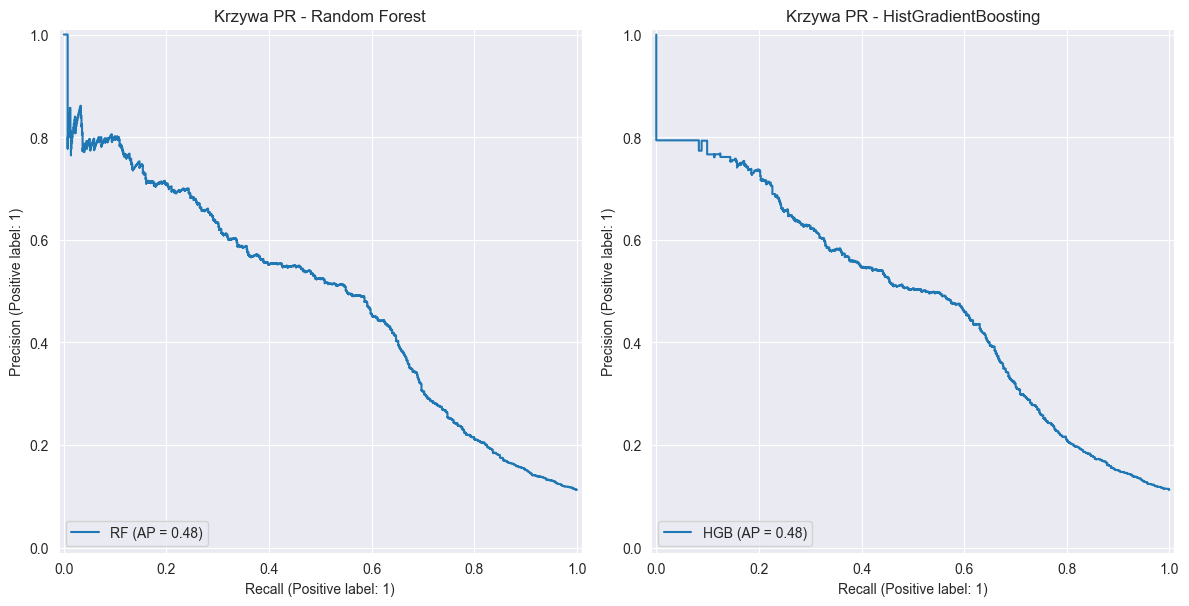

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
PrecisionRecallDisplay.from_estimator(
    best_rf_estimator, X_test, y_test, ax=axes[0], name="RF"
)
axes[0].set_title("Krzywa PR - Random Forest")

PrecisionRecallDisplay.from_estimator(
    best_hgb_estimator, X_test, y_test, ax=axes[1], name="HGB"
)
axes[1].set_title("Krzywa PR - HistGradientBoosting")

plt.tight_layout()
plt.show()

Statystyka AP (Average precision) na poziomie 0.48 mówi nam o tym, że obydwa nasze wytrenowane modele, przewidują klienta chętnego do wybrania lokaty średnio ponad 4x razy skuteczniej, niż model losowy (0.11)

### Wnioski dotyczące wyboru finałowego modelu:

Zarówno model lasu losowego, jak i model boostingowy wypadły niemal identycznie w naszych zestawieniach. Przyczyną jest prawdopodobnie fakt, że osiągnęlismy swoisty "szklany sufit" dla naszych danych, i bez naszego feature engeenieringu nie jesteśmy w stanie osiągnąć lepszego rezultatu.

Ostatecznie decydujemy się na model Random Forest, ponieważ w dalszej części projektu będziemy wykorzystywać metodę Shapley Values, w celu lepszej interpretowalności naszego modelu, a algorytm RF sprawdza się lepiej w stosowaniu tego rozwiązania.

### Zalecenia odnośnie progu odcięcia

Po analizie krzywej PR decydujemy się zmianę zalecanego progu predykcji na wartość, taką która będzie odpowiadała poziomowi recall ~ 0.65. Taka decyzja jest spowodowana taktyką biznesową wynikającą z niskiego kosztu fałszywych pozytywów, względem potencjalnego zysku z klienta true positive. W rzeczwywistości, jeśli bank potrzebowałby jeszcze większej płynności gotówki podjąłby prawdopodobnie jeszcze bardziej drastyczne kroki, próbując "zdobyć" jeszcze większy odsetek klientów, kosztem gorszej precyzji.

In [111]:
test_probs = best_rf_estimator.predict_proba(X_test)[:, 1]
train_probs = best_rf_estimator.predict_proba(X_train)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, test_probs)
target_recall = 0.65

In [112]:
idx = np.argmin(np.abs(recalls - target_recall))
print(f"Dla punktu Recall = {recalls[idx]:.4f}:")
print(f" - odpowiadająca precyzja to: {precisions[idx]:.4f}")
print(f" - szukany threshold to: {thresholds[idx]:.4f}")

custom_threshold = thresholds[idx]

Dla punktu Recall = 0.6498:
 - odpowiadająca precyzja to: 0.4020
 - szukany threshold to: 0.3759


In [116]:
plots_config = [
    (y_train, train_probs, 0.5, "Trening thold=0.5"),
    (y_test, test_probs, 0.5, "Test thold=0.5"),
    (y_train, train_probs, custom_threshold, f"Trening thold={custom_threshold:.3f}"),
    (y_test, test_probs, custom_threshold, f"Test thold={custom_threshold:.3f}")
]

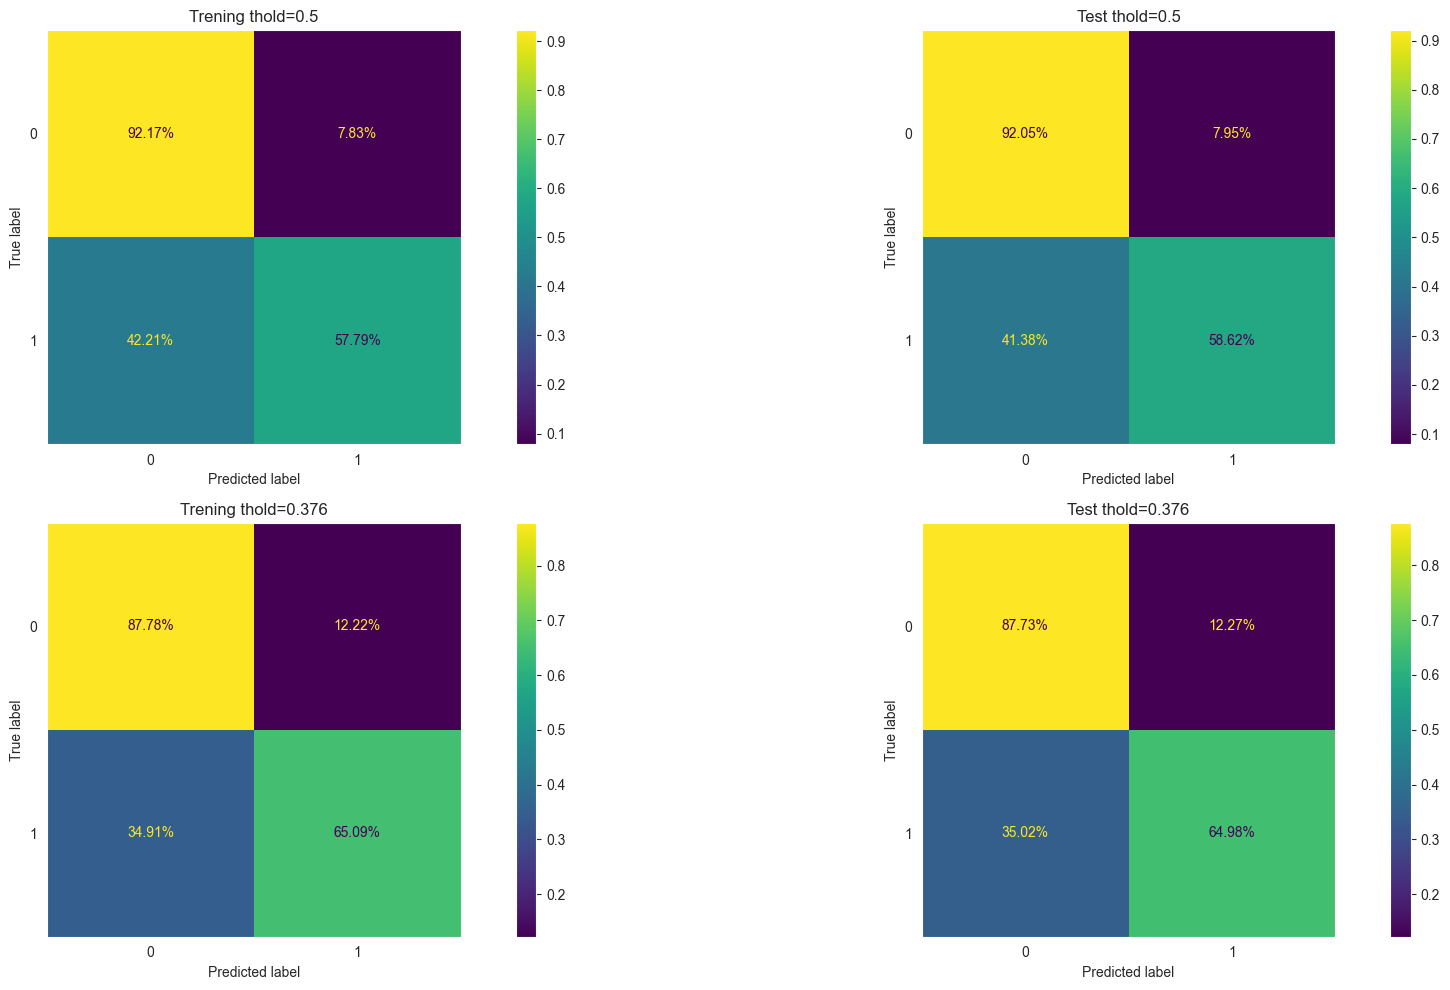

In [121]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
axes = axes.flatten()

for ax, (y_true, probs, thold, title) in zip(axes, plots_config):
    y_pred = (probs >= thold).astype(int)
    cm = confusion_matrix(y_true, y_pred, normalize='true')

    disp = ConfusionMatrixDisplay(cm)
    disp.plot(ax=ax, values_format='.2%', cmap='viridis')

    ax.set_title(title)
    ax.grid(False)

plt.tight_layout()
plt.show()

Osiągniete wyniki na zbiorze treningowym i testowym są bardzo porównywalne co pozwala nam stwierdzić, że nie mamy doczynienia z przeuczeniem modelu.

Z kolei dla proponowanego przez nas progu odcięcia 0.376 odstek true positivów zwiększył się (+6.36 p.p.) w większym stopniu niż odstek false positivów (+4.32 p.p.).

In [ ]:
MODEL_SAVE_PATH = '../models/RF_model_v2.joblib'
joblib.dump(best_rf_estimator, MODEL_SAVE_PATH)